In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import *

In [2]:
dataset = BinaryDataset('Node123_loop')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(20))
feature_names = [f'Bus {i+1}' for i in range(1, dataset.n_buses + 1)]

In [3]:
normal_df = train_dataset.dataset.data_df
outage_df = train_dataset.dataset.data_outage_df

In [4]:
normal_df.head()

,Bus_2,Bus_3,Bus_4,Bus_5,Bus_6,Bus_7,Bus_8,Bus_9,Bus_10,Bus_11,...,Bus_114,Bus_115,Bus_116,Bus_117,Bus_118,Bus_119,Bus_120,Bus_121,Bus_122,Bus_123
0,1.801364,3.704511,3.754289,3.764920,3.773261,3.777110,3.707374,5.506988,7.057932,7.060923,...,17.310101,17.327247,17.292715,17.304897,17.287700,17.273924,17.182208,17.345864,17.381064,17.392152
1,1.700467,3.486971,3.545923,3.570218,3.549175,3.551332,3.508015,5.149739,6.575637,6.589151,...,15.733709,15.756435,15.734489,15.744176,15.737993,15.723991,15.656326,15.771888,15.799928,15.802383
2,1.666035,3.416380,3.496297,3.522380,3.512061,3.513421,3.418026,5.038076,6.426357,6.429211,...,14.983951,14.984803,15.020405,15.040418,15.025668,15.027482,14.966476,15.090289,15.118963,15.120374
3,1.609353,3.300769,3.361242,3.369764,3.389278,3.403229,3.307711,4.885799,6.244488,6.253443,...,15.408797,15.418200,15.391230,15.400667,15.389203,15.380218,15.302104,15.429762,15.460303,15.465792
4,1.717274,3.521722,3.593853,3.603124,3.637374,3.657876,3.551213,5.184229,6.612979,6.625339,...,15.826042,15.848626,15.850994,15.856728,15.874177,15.891975,15.824668,15.963342,16.009445,16.035745


In [5]:
outage_df.head()

,Bus_2,Bus_3,Bus_4,Bus_5,Bus_6,Bus_7,Bus_8,Bus_9,Bus_10,Bus_11,...,Bus_114,Bus_115,Bus_116,Bus_117,Bus_118,Bus_119,Bus_120,Bus_121,Bus_122,Bus_123
0,1.801364,3.704511,3.754289,3.764920,3.773261,3.777110,3.707374,5.506988,7.057932,7.060923,...,17.854202,17.871349,17.965012,17.977194,18.087155,18.199887,18.265587,18.271827,18.307027,18.318115
1,1.700467,3.486971,3.545923,3.570218,3.549175,3.551332,3.508015,5.149739,6.575637,6.589151,...,16.194044,16.216770,16.303283,16.312970,16.414370,16.507398,16.572915,16.555295,16.583336,16.585791
2,1.666035,3.416380,3.496297,3.522380,3.512061,3.513421,3.418026,5.038076,6.426357,6.429211,...,15.423756,15.424608,15.563832,15.583845,15.671879,15.775951,15.842186,15.838758,15.867431,15.868843
3,1.609353,3.300769,3.361242,3.369764,3.389278,3.403229,3.307711,4.885799,6.244488,6.253443,...,15.842844,15.852247,15.927543,15.936979,16.026953,16.118887,16.166349,16.168431,16.198973,16.204461
4,1.717274,3.521722,3.593853,3.603124,3.637374,3.657876,3.551213,5.184229,6.612979,6.625339,...,16.405387,16.427970,16.566838,16.572572,16.725416,16.877915,16.978220,16.949282,16.995386,17.021686


In [6]:
merged_df = pd.concat([normal_df, outage_df], ignore_index=True)
merged_df.head()

,Bus_2,Bus_3,Bus_4,Bus_5,Bus_6,Bus_7,Bus_8,Bus_9,Bus_10,Bus_11,...,Bus_114,Bus_115,Bus_116,Bus_117,Bus_118,Bus_119,Bus_120,Bus_121,Bus_122,Bus_123
0,1.801364,3.704511,3.754289,3.764920,3.773261,3.777110,3.707374,5.506988,7.057932,7.060923,...,17.310101,17.327247,17.292715,17.304897,17.287700,17.273924,17.182208,17.345864,17.381064,17.392152
1,1.700467,3.486971,3.545923,3.570218,3.549175,3.551332,3.508015,5.149739,6.575637,6.589151,...,15.733709,15.756435,15.734489,15.744176,15.737993,15.723991,15.656326,15.771888,15.799928,15.802383
2,1.666035,3.416380,3.496297,3.522380,3.512061,3.513421,3.418026,5.038076,6.426357,6.429211,...,14.983951,14.984803,15.020405,15.040418,15.025668,15.027482,14.966476,15.090289,15.118963,15.120374
3,1.609353,3.300769,3.361242,3.369764,3.389278,3.403229,3.307711,4.885799,6.244488,6.253443,...,15.408797,15.418200,15.391230,15.400667,15.389203,15.380218,15.302104,15.429762,15.460303,15.465792
4,1.717274,3.521722,3.593853,3.603124,3.637374,3.657876,3.551213,5.184229,6.612979,6.625339,...,15.826042,15.848626,15.850994,15.856728,15.874177,15.891975,15.824668,15.963342,16.009445,16.035745


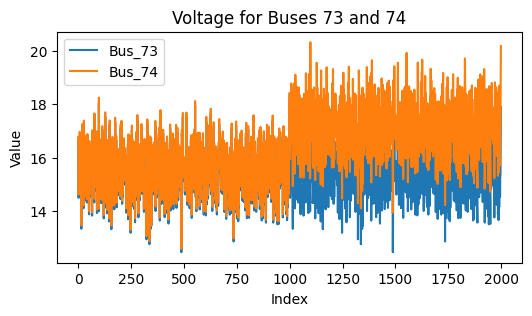

In [16]:
# Select the columns for buses 73-76
buses = ['Bus_73', 'Bus_74']


# Plot the data for normal_df
plt.figure(figsize=(6, 3))
for bus in buses:
    plt.plot(merged_df[bus], label=f'{bus}')
plt.title('Voltage for Buses 73 and 74')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()